<a href="https://colab.research.google.com/github/lllda06/DATA-ANALYSIS/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##0. Импорт сторонних библиотек

In [375]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle

##1. Загрузка данных

In [252]:
files.upload()
df = pd.read_csv('vehicles_dataset.csv')
df.head()

Saving vehicles_dataset.csv to vehicles_dataset (2).csv


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,type,paint_color,image_url,description,county,state,lat,long,posting_date,price_category
0,7308295377,https://chattanooga.craigslist.org/ctd/d/chatt...,chattanooga,https://chattanooga.craigslist.org,54990,2020.0,ram,2500 crew cab big horn,good,NaN,...,pickup,silver,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,NaN,tn,35.060000,-85.250000,2021-04-17T12:30:50-0400,high
1,7316380095,https://newjersey.craigslist.org/ctd/d/carlsta...,north jersey,https://newjersey.craigslist.org,16942,2016.0,ford,explorer 4wd 4dr xlt,NaN,6 cylinders,...,SUV,black,https://images.craigslist.org/00x0x_26jl9F0cnL...,***Call Us for more information at: 201-635-14...,NaN,nj,40.821805,-74.061962,2021-05-03T15:40:21-0400,medium
2,7313733749,https://reno.craigslist.org/ctd/d/atlanta-2017...,reno / tahoe,https://reno.craigslist.org,35590,2017.0,volkswagen,golf r hatchback,good,NaN,...,sedan,NaN,https://images.craigslist.org/00y0y_eeZjWeiSfb...,Carvana is the safer way to buy a car During t...,NaN,ca,33.779214,-84.411811,2021-04-28T03:52:20-0700,high
3,7308210929,https://fayetteville.craigslist.org/ctd/d/rale...,fayetteville,https://fayetteville.craigslist.org,14500,2013.0,toyota,rav4,NaN,NaN,...,wagon,white,https://images.craigslist.org/00606_iGe5iXidib...,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,NaN,nc,35.715954,-78.655304,2021-04-17T10:08:57-0400,medium
4,7316474668,https://newyork.craigslist.org/lgi/cto/d/baldw...,new york city,https://newyork.craigslist.org,21800,2021.0,nissan,altima,new,4 cylinders,...,NaN,NaN,https://images.craigslist.org/00V0V_3pSOiPZ3Sd...,2021 Nissan Altima Sv with Only 8 K Miles Titl...,NaN,ny,40.654800,-73.609700,2021-05-03T18:32:06-0400,medium


#2. Data Preparation

##2.1 Первичный анализ структуры данных

In [253]:
print(df.shape)

(10050, 27)


In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10050 non-null  int64  
 1   url             10050 non-null  object 
 2   region          10050 non-null  object 
 3   region_url      10050 non-null  object 
 4   price           10050 non-null  int64  
 5   year            10014 non-null  float64
 6   manufacturer    9665 non-null   object 
 7   model           9921 non-null   object 
 8   condition       6268 non-null   object 
 9   cylinders       5953 non-null   object 
 10  fuel            9987 non-null   object 
 11  odometer        10007 non-null  float64
 12  title_status    9884 non-null   object 
 13  transmission    10005 non-null  object 
 14  VIN             6086 non-null   object 
 15  drive           7026 non-null   object 
 16  size            2825 non-null   object 
 17  type            7845 non-null  

Анализ показал, что в наборе данных присутствуют признаки типов int64, float64 и object. Также были обнаружены пропущенные значения в ряде столбцов, требующие дальнейшей обработки.

In [255]:
df.describe()

,id,price,year,odometer,county,lat,long
count,1.005000e+04,1.005000e+04,10014.000000,1.000700e+04,0.0,9951.000000,9951.000000
mean,7.311544e+09,2.068429e+04,2010.917815,9.565719e+04,NaN,38.590164,-94.161564
std,4.475414e+06,1.243216e+05,9.697849,8.657948e+04,NaN,5.844756,18.123096
min,7.208550e+09,5.000000e+02,1915.000000,0.000000e+00,NaN,-67.144243,-158.069300
25%,7.308193e+09,7.900000e+03,2008.000000,3.899450e+04,NaN,34.830000,-110.447150
50%,7.312756e+09,1.574950e+04,2013.000000,8.837700e+04,NaN,39.285100,-87.999100
75%,7.315275e+09,2.799000e+04,2017.000000,1.370000e+05,NaN,42.427590,-80.830000
max,7.317090e+09,1.234568e+07,2022.000000,3.245000e+06,NaN,64.947500,173.885502


## 2.2 Преобразование типов данных

In [256]:
df['posting_date'] = pd.to_datetime(
    df['posting_date'],
    utc=True
)

Остальные признаки на данном этапе были оставлены без изменений, поскольку часть из них содержала пропущенные значения, которые необходимо обработать перед дальнейшими преобразованиями.

## 2.3. Исследование пропущенных значений

In [257]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,36
manufacturer,385
model,129
condition,3782
cylinders,4097


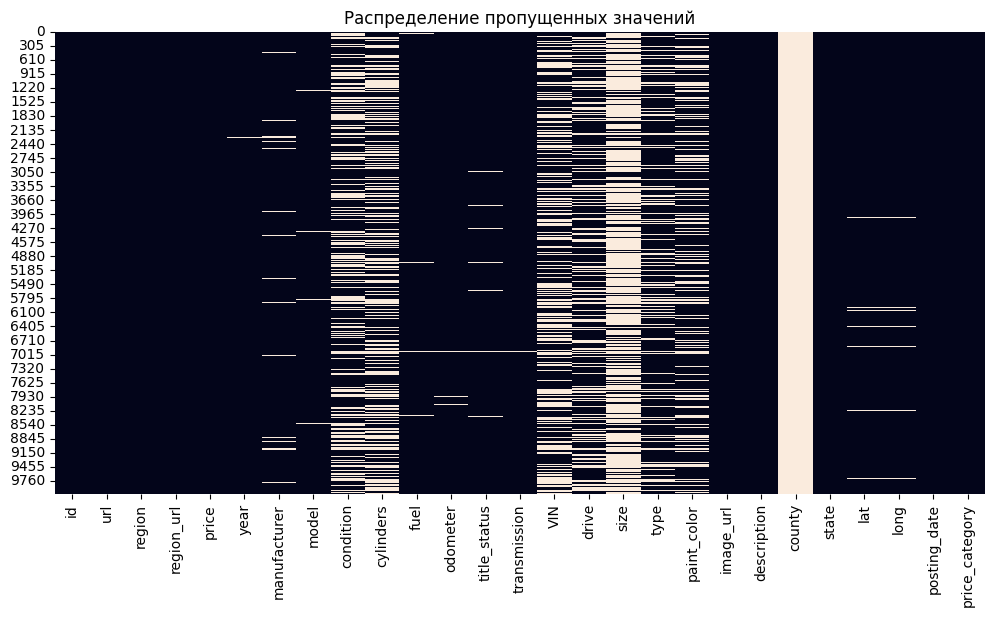

In [258]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Распределение пропущенных значений')
plt.show()

Наибольшее количество пропусков наблюдается в признаках county, size, cylinders, VIN, condition, drive и paint_color.

## 2.4 Обработка пропущенных значений

In [259]:
df = df.drop(columns='county')

Признак VIN содержит 39,4% пропусков и представляет собой уникальный идентификатор транспортного средства. Поскольку данный признак не несёт значимой информации для анализа стоимости автомобиля, он был исключён из исследования.

In [260]:
df = df.drop(columns='VIN')

В ходе анализа было выявлено, что признак county полностью состоит из пропущенных значений и не содержит полезной информации для исследования. В связи с этим данный столбец был удалён

In [261]:
df['year'] = df['year'].fillna(df['year'].median())
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['lat'] = df['lat'].fillna(df['lat'].median())
df['long'] = df['long'].fillna(df['long'].median())

In [262]:
df['manufacturer'] = df['manufacturer'].fillna(
    df['manufacturer'].mode()[0]
)

df['fuel'] = df['fuel'].fillna(
    df['fuel'].mode()[0]
)

df['title_status'] = df['title_status'].fillna(
    df['title_status'].mode()[0]
)

df['transmission'] = df['transmission'].fillna(
    df['transmission'].mode()[0]
)

После заполнения пропусков признак year был преобразован в целочисленный тип данных.

In [263]:
df['year'] = df['year'].astype(int)

In [264]:
print(df['condition'].value_counts(dropna=False))
print(df['cylinders'].value_counts(dropna=False))
print(df['drive'].value_counts(dropna=False))

condition
NaN          3782
good         3134
excellent    2429
like new      482
fair          179
new            31
salvage        13
Name: count, dtype: int64
cylinders
NaN             4097
6 cylinders     2288
4 cylinders     1825
8 cylinders     1726
5 cylinders       46
10 cylinders      29
other             25
3 cylinders       13
12 cylinders       1
Name: count, dtype: int64
drive
4wd    3054
NaN    3024
fwd    2563
rwd    1409
Name: count, dtype: int64


In [265]:
df = df.drop(columns='size')

Почти 72% данных отсутствует

In [266]:
df = df.drop(columns='image_url')

Не нужен для анализа цены

In [267]:
df = df.drop(columns='description')

In [268]:
df['model'] = df['model'].fillna('unknown')

128 пропусков из 10000 (1.3%)

In [269]:
df['condition'] = df['condition'].fillna('unknown')
df['cylinders'] = df['cylinders'].fillna('unknown')
df['drive'] = df['drive'].fillna('unknown')
df['type'] = df['type'].fillna('unknown')
df['paint_color'] = df['paint_color'].fillna('unknown')

In [270]:
df = df.dropna(subset=['posting_date'])

In [271]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0


## 2.5 Проверка данных на дубликаты

In [272]:
df = df.drop_duplicates()

In [273]:
print(df.duplicated().sum())

0


## 2.6 Поиск аномальных значений

In [274]:
df[['price', 'year', 'odometer']].describe()

,price,year,odometer
count,9.998000e+03,9998.000000,9.998000e+03
mean,2.068098e+04,2010.934987,9.564475e+04
std,1.246353e+05,9.656332,8.648256e+04
min,5.000000e+02,1915.000000,0.000000e+00
25%,7.900000e+03,2008.000000,3.914375e+04
50%,1.575650e+04,2013.000000,8.837700e+04
75%,2.799000e+04,2017.000000,1.368750e+05
max,1.234568e+07,2022.000000,3.245000e+06


По результатам описательной статистики установлено, что средняя стоимость автомобиля составляет 20 678 долларов, медианная стоимость — 15 749 долларов. Максимальная цена автомобиля достигает 12 345 680 долларов, что существенно превышает медианное значение и может свидетельствовать о наличии выбросов в данных. Аналогичная ситуация наблюдается для признака пробега (odometer), максимальное значение которого составляет 3 245 000 миль. Данные наблюдения требуют дополнительного анализа на этапе поиска аномалий.

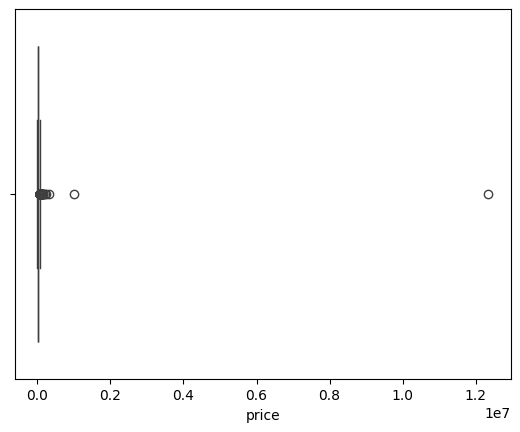

In [275]:
sns.boxplot(x=df['price'])
plt.show()

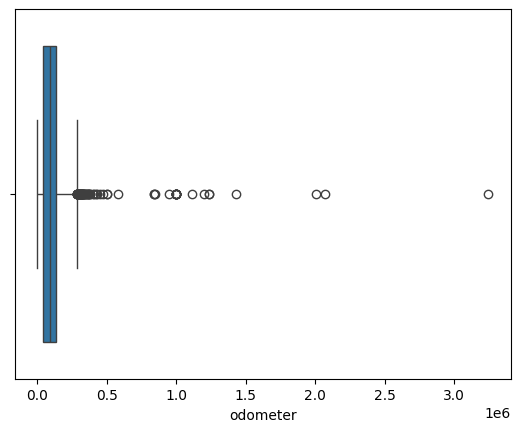

In [276]:
sns.boxplot(x=df['odometer'])
plt.show()

In [277]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [278]:
print(lower)
print(upper)

-22235.0
58125.0


In [279]:
df = df[
    (df['price'] >= lower) &
    (df['price'] <= upper)
]

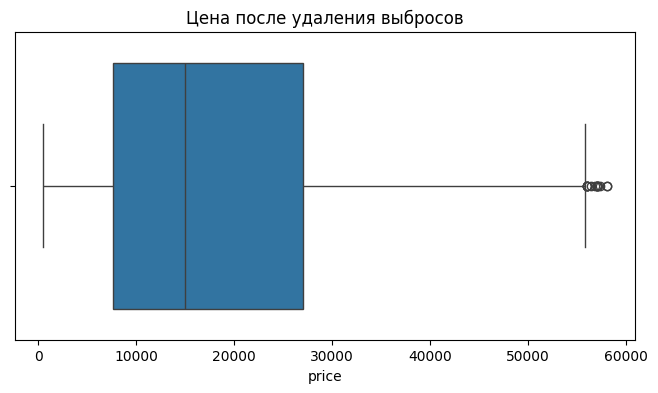

In [280]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title('Цена после удаления выбросов')
plt.show()

In [281]:
print("Размер датасета:", df.shape)

print("Пропуски:")
print(df.isnull().sum().sum())

print("Дубликаты:")
print(df.duplicated().sum())

Размер датасета: (9783, 22)
Пропуски:
0
Дубликаты:
0


In [282]:
df['year'].describe()

,year
count,9783.000000
mean,2010.841051
std,9.615613
min,1915.000000
25%,2008.000000
50%,2013.000000
75%,2017.000000
max,2022.000000


Удаление аномальных годов выпуска

In [283]:
df = df[
    (df['year'] >= 1980) &
    (df['year'] <= 2022)
]

In [284]:
df['year'].describe()

,year
count,9588.000000
mean,2011.829683
std,6.396131
min,1980.000000
25%,2008.000000
50%,2013.000000
75%,2017.000000
max,2022.000000


In [285]:
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0


In [286]:
df[['price', 'year', 'odometer']].describe()

,price,year,odometer
count,9588.00000,9588.000000,9.588000e+03
mean,18126.38423,2011.829683,9.744222e+04
std,12543.86306,6.396131,8.065002e+04
min,500.00000,1980.000000,0.000000e+00
25%,7674.75000,2008.000000,4.077850e+04
50%,15269.00000,2013.000000,9.099950e+04
75%,26995.00000,2017.000000,1.390000e+05
max,57999.00000,2022.000000,2.070000e+06


После анализа распределения пробега было принято решение не удалять оставшиеся редкие значения, так как они могут соответствовать коммерческому транспорту и не оказывают существенного влияния на дальнейший анализ.

1. удалено около 410 записей с аномальными ценами и годами;
2. максимальная цена стала реалистичной;
3. минимальный год выпуска больше не содержит явных ошибок;
4. датасет выглядит гораздо чище

Размер датасета после очистки

In [287]:
print("Размер датасета:", df.shape)
print("Количество пропусков:", df.isnull().sum().sum())
print("Количество дубликатов:", df.duplicated().sum())

Размер датасета: (9588, 22)
Количество пропусков: 0
Количество дубликатов: 0


## В ходе подготовки данных были выполнены:

1. преобразование признака posting_date к типу datetime;
2. анализ пропущенных значений;
3. удаление признаков county, VIN, size, содержащих большое количество пропусков;
4. заполнение числовых пропусков медианными значениями;
5. заполнение категориальных пропусков модой и значением unknown;
6. удаление строк с отсутствующей датой публикации;
7. удаление дубликатов;
8. обнаружение и удаление выбросов в признаке price методом межквартильного размаха (IQR);
9. удаление аномальных значений года выпуска.

После выполнения подготовки данные не содержат пропусков и готовы к дальнейшему анализу и построению моделей.

# 3. Feature engineering

## 3.1 Анализ признаков перед преобразованием

In [288]:
df = df.drop(columns=['id'])

In [289]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   url             9588 non-null   object             
 1   region          9588 non-null   object             
 2   region_url      9588 non-null   object             
 3   price           9588 non-null   int64              
 4   year            9588 non-null   int64              
 5   manufacturer    9588 non-null   object             
 6   model           9588 non-null   object             
 7   condition       9588 non-null   object             
 8   cylinders       9588 non-null   object             
 9   fuel            9588 non-null   object             
 10  odometer        9588 non-null   float64            
 11  title_status    9588 non-null   object             
 12  transmission    9588 non-null   object             
 13  drive           9588 non-null   objec

In [290]:
df.select_dtypes(include='object').columns

Index(['url', 'region', 'region_url', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type',
       'paint_color', 'state', 'price_category'],
      dtype='object')

In [291]:
constant_cols = [
    col
    for col in df.columns
    if df[col].nunique() <= 1
]

print(constant_cols)

[]


## 3.2 Создание новых признаков из даты

In [292]:
df['posting_year'] = df['posting_date'].dt.year
df['posting_month'] = df['posting_date'].dt.month
df['posting_dayofweek'] = df['posting_date'].dt.dayofweek

Проверка распределения

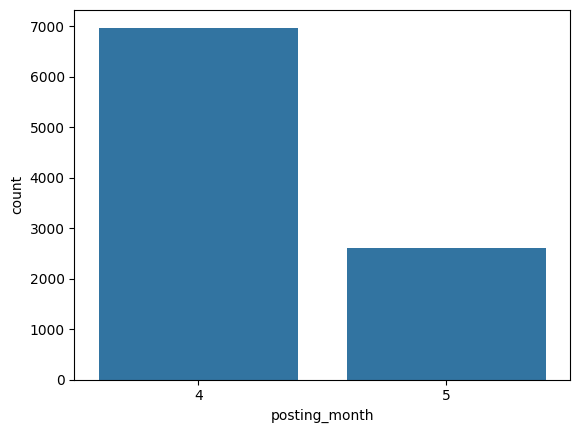

In [293]:
sns.countplot(
    x='posting_month',
    data=df
)
plt.show()

Т.к в столбцк posting_month только два месяца - апрель и май, а также в столбце posting_year один год - 2021, то данные признаки являются бесполезными и их можно удалить

In [294]:
df = df.drop(columns=['posting_year'])
df = df.drop(columns=['posting_month'])

In [295]:
print(df['posting_dayofweek'].value_counts())

posting_dayofweek
1    1782
0    1655
4    1498
5    1416
3    1191
2    1062
6     984
Name: count, dtype: int64


## 3.3 Создание признака возраста автомобиля

In [296]:
df['car_age'] = (
    df['posting_date'].dt.year - df['year']
)

In [297]:
df = df.drop(columns=['posting_date'])

In [298]:
df[['year', 'car_age']].head()

,year,car_age
0,2020,1
1,2016,5
2,2017,4
3,2013,8
4,2021,0


In [299]:
df['car_age'].describe()

,car_age
count,9588.000000
mean,9.170317
std,6.396131
min,-1.000000
25%,4.000000
50%,8.000000
75%,13.000000
max,41.000000


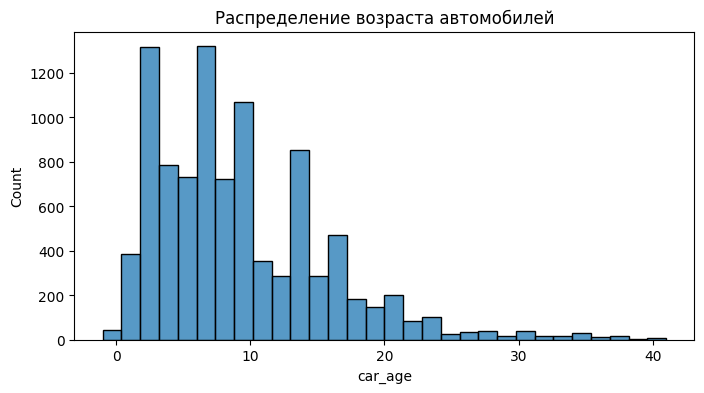

In [300]:
plt.figure(figsize=(8,4))
sns.histplot(
    df['car_age'],
    bins=30
)
plt.title('Распределение возраста автомобилей')
plt.show()

На основе признака **year** был создан новый признак **car_age**, отражающий возраст автомобиля на момент публикации обьявления.

## 3.4 Удаление неинформативных признаков

In [301]:
df.columns

Index(['url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model',
       'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'drive', 'type', 'paint_color', 'state', 'lat', 'long',
       'price_category', 'posting_dayofweek', 'car_age'],
      dtype='object')

Удаление ненужных столюцов

In [302]:
df = df.drop(columns=['url', 'region_url'])

In [303]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'lat', 'long',
       'price_category', 'posting_dayofweek', 'car_age'],
      dtype='object')

In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region             9588 non-null   object 
 1   price              9588 non-null   int64  
 2   year               9588 non-null   int64  
 3   manufacturer       9588 non-null   object 
 4   model              9588 non-null   object 
 5   condition          9588 non-null   object 
 6   cylinders          9588 non-null   object 
 7   fuel               9588 non-null   object 
 8   odometer           9588 non-null   float64
 9   title_status       9588 non-null   object 
 10  transmission       9588 non-null   object 
 11  drive              9588 non-null   object 
 12  type               9588 non-null   object 
 13  paint_color        9588 non-null   object 
 14  state              9588 non-null   object 
 15  lat                9588 non-null   float64
 16  long               9588 non-

## 3.5 Подготовка категориальных признаков (OneHotEncoder)

Целевая переменная (target)

In [305]:
y = df['price_category']

Входные признаки (features)

In [306]:
X = df.drop(columns=['price_category', 'price'])

In [307]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols

Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')

In [308]:
for col in cat_cols:
    print(col, X[col].nunique())

region 392
manufacturer 39
model 3271
condition 7
cylinders 9
fuel 5
title_status 6
transmission 3
drive 4
type 14
paint_color 13
state 51


Удаление проблемных признаков

In [309]:
X = X.drop(columns=['region', 'model'])

In [310]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Модель умеет работать с числами, поэтому текст превращается в набор 0 и 1.

In [311]:
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [312]:
cat_cols = X_train.select_dtypes(include='object').columns

num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

In [313]:
print('Категориальные:')
print(cat_cols)

print('\nЧисловые:')
print(num_cols)

Категориальные:
Index(['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
       'transmission', 'drive', 'type', 'paint_color', 'state'],
      dtype='object')

Числовые:
Index(['year', 'odometer', 'lat', 'long', 'car_age'], dtype='object')


In [314]:
encoder.fit(X_train[cat_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

Кодирование train

In [315]:
X_train_encoded = encoder.transform(
    X_train[cat_cols]
)

Кодирование test

In [316]:
X_test_encoded = encoder.transform(
    X_test[cat_cols]
)

Превращение результата в DataFrame

In [317]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

Для test:

In [318]:
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

Сбрасываем индексы

In [319]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

X_train_encoded = X_train_encoded.reset_index(drop=True)
X_test_encoded = X_test_encoded.reset_index(drop=True)

Удаляем старые текстовые колонки

In [320]:
X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

## 3.6 Масштабирование числовых признаков

In [321]:
df.select_dtypes(include='number').columns

Index(['price', 'year', 'odometer', 'lat', 'long', 'posting_dayofweek',
       'car_age'],
      dtype='object')

Удаление столбца **year** т.к есть **car_age**

In [322]:
df = df.drop(columns=['year'])

Приводим признаки к одному масштабу.

In [323]:
scaler = StandardScaler()

In [324]:
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

In [325]:
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [326]:
X_train = pd.concat(
    [
        X_train,
        X_train_encoded
    ],
    axis=1
)

In [327]:
X_test = pd.concat(
    [
        X_test,
        X_test_encoded
    ],
    axis=1
)

In [328]:
print(X_train.shape)
print(X_test.shape)

(7191, 157)
(2397, 157)


In [329]:
print(X_train.head())

       year  odometer       lat      long  posting_dayofweek   car_age  \
0  0.337181 -0.609717  0.122106  0.979112                  3 -0.337181   
1 -1.076438  0.175137  0.873756 -1.264512                  5  1.076438   
2 -0.448163  0.742864 -0.847920 -1.366582                  6  0.448163   
3  0.180113 -0.240587  1.335466 -1.430552                  4 -0.180113   
4 -0.762301 -0.016265 -1.568658 -0.101073                  3  0.762301   

   manufacturer_acura  manufacturer_alfa-romeo  manufacturer_audi  \
0                 0.0                      0.0                0.0   
1                 0.0                      0.0                0.0   
2                 0.0                      0.0                0.0   
3                 0.0                      0.0                0.0   
4                 0.0                      0.0                0.0   

   manufacturer_bmw  ...  state_sd  state_tn  state_tx  state_ut  state_va  \
0               0.0  ...       0.0       0.0       0.0       0

In [330]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7191 entries, 0 to 7190
Columns: 157 entries, year to state_wy
dtypes: float64(156), int32(1)
memory usage: 8.6 MB
None


## 3.7 Корреляционный анализ

Связи признков

In [331]:
corr = df.corr(
    numeric_only=True
)

Тепловая карта

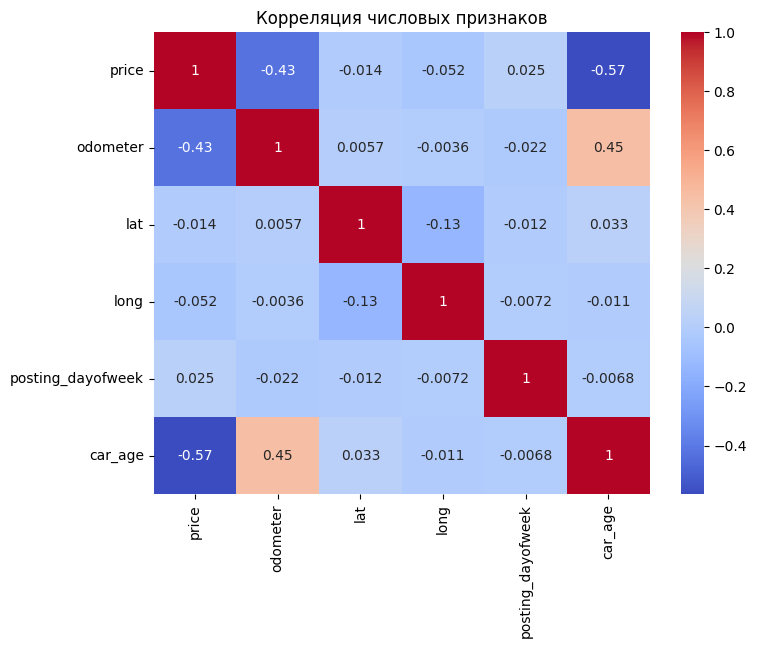

In [332]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Корреляция числовых признаков')
plt.show()

In [333]:
corr['price'].sort_values(
    ascending=False
)

,price
price,1.000000
posting_dayofweek,0.025207
lat,-0.014285
long,-0.051578
odometer,-0.428769
car_age,-0.565160


1. car_age - чем старше автомобиль, тем ниже цена
2. odometer - чем больше пробег, тем ниже цена
3. long - практически нет связи
4. lat - практически нет связи
5. posting_dayofweek - практически нет связи

Для исследования взаимосвязей между признаками была построена матрица корреляций числовых переменных. Анализ показал сильную обратную связь между признаками year и car_age, поскольку возраст автомобиля был рассчитан на основе года выпуска. Во избежание мультиколлинеарности в дальнейшем моделировании был оставлен признак car_age.

## 3.8 Финальная проверка датасета

In [334]:
df.shape

(9588, 19)

In [335]:
print(df.isnull().sum().sum())

0


In [336]:
print(df.duplicated().sum())

16


In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region             9588 non-null   object 
 1   price              9588 non-null   int64  
 2   manufacturer       9588 non-null   object 
 3   model              9588 non-null   object 
 4   condition          9588 non-null   object 
 5   cylinders          9588 non-null   object 
 6   fuel               9588 non-null   object 
 7   odometer           9588 non-null   float64
 8   title_status       9588 non-null   object 
 9   transmission       9588 non-null   object 
 10  drive              9588 non-null   object 
 11  type               9588 non-null   object 
 12  paint_color        9588 non-null   object 
 13  state              9588 non-null   object 
 14  lat                9588 non-null   float64
 15  long               9588 non-null   float64
 16  price_category     9588 non-

## 3.10 Сохранение итогового датасета

In [338]:
df.to_csv(
    'vehicles_final.csv',
    index=False
)

Проверка

In [339]:
final_df = pd.read_csv('vehicles_final.csv')

final_df.head()

,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,lat,long,price_category,posting_dayofweek,car_age
0,chattanooga,54990,ram,2500 crew cab big horn,good,unknown,diesel,27442.0,clean,other,4wd,pickup,silver,tn,35.060000,-85.250000,high,5,1
1,north jersey,16942,ford,explorer 4wd 4dr xlt,unknown,6 cylinders,gas,60023.0,clean,automatic,4wd,SUV,black,nj,40.821805,-74.061962,medium,0,5
2,reno / tahoe,35590,volkswagen,golf r hatchback,good,unknown,gas,14048.0,clean,other,unknown,sedan,unknown,ca,33.779214,-84.411811,high,2,4
3,fayetteville,14500,toyota,rav4,unknown,unknown,gas,117291.0,clean,automatic,fwd,wagon,white,nc,35.715954,-78.655304,medium,5,8
4,new york city,21800,nissan,altima,new,4 cylinders,gas,8000.0,clean,automatic,unknown,unknown,unknown,ny,40.654800,-73.609700,medium,0,0


В ходе этапа Feature Engineering были созданы новые признаки на основе имеющихся данных. Из признака **posting_date** были извлечены признаки **posting_year**, **posting_month** и **posting_dayofweek**. После анализа распределения значений признаки **posting_year** и **posting_month** были удалены как неинформативные, поскольку содержали недостаточное разнообразие значений. На основе года выпуска автомобиля был создан новый признак **car_age**, отражающий возраст автомобиля на момент публикации объявления.

Для подготовки данных к машинному обучению была выделена целевая переменная **price_category**, после чего категориальные признаки были преобразованы с помощью метода One-Hot Encoding, что позволило представить текстовые данные в числовом формате. В результате кодирования количество признаков существенно увеличилось и составило 3820 признаков в матрице признаков X.

Числовые признаки были стандартизированы с использованием StandardScaler, что позволило привести их к единому масштабу и уменьшить влияние различий в диапазонах значений на работу алгоритмов машинного обучения.

Также были удалены неинформативные признаки (**url**, **region_url**, **posting_date**), не содержащие полезной информации для построения модели. Проведён корреляционный анализ числовых признаков, который показал, что наиболее сильную связь с ценой автомобиля имеют признаки **car_age** и **odometer**. Было установлено, что с увеличением возраста автомобиля и пробега его стоимость, как правило, снижается.

В результате был сформирован набор данных для построения моделей машинного обучения: матрица признаков X содержит 9588 наблюдений и 3820 признаков, а целевая переменная y представлена категориями стоимости автомобилей (low, medium, high). Подготовленные данные не содержат пропусков и дубликатов и готовы к переходу к этапу моделирования.

# 4. Modelling

## Обьявление моделей

*Создание моделей*

**Логистическая регрессия**

**Случайный лес**

In [340]:
lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=3000, random_state=42)

**Random Forest**

In [341]:
rf = RandomForestClassifier(
    random_state=42
)

**Многослойный персептрон**

In [342]:
mlp = MLPClassifier(
    random_state=42,
    max_iter=1000
)

## 4.5 Кросс-валидация базовых моделей

Проверяем каждую модель

**Logistic Regression**

In [343]:
print(X.shape)

(9588, 16)


In [344]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9588 entries, 0 to 10049
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               9588 non-null   int64  
 1   manufacturer       9588 non-null   object 
 2   condition          9588 non-null   object 
 3   cylinders          9588 non-null   object 
 4   fuel               9588 non-null   object 
 5   odometer           9588 non-null   float64
 6   title_status       9588 non-null   object 
 7   transmission       9588 non-null   object 
 8   drive              9588 non-null   object 
 9   type               9588 non-null   object 
 10  paint_color        9588 non-null   object 
 11  state              9588 non-null   object 
 12  lat                9588 non-null   float64
 13  long               9588 non-null   float64
 14  posting_dayofweek  9588 non-null   int32  
 15  car_age            9588 non-null   int64  
dtypes: float64(3), int32(1), int

In [345]:
lr_cv = cross_val_score(lr, X_train, y_train, cv=3, n_jobs=-1)

In [346]:
print(lr_cv.mean())

0.7549714921429564


Для оценки качества логистической регрессии была применена 3-кратная кросс-валидация. Среднее значение метрики Accuracy составило 0.755. Полученный результат показывает, что модель способна корректно классифицировать около 75.5% объектов и может использоваться как базовая модель для дальнейшего сравнения с более сложными алгоритмами.

**Random Forest**


In [347]:
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

In [348]:
print(rf_cv.mean())

0.7851475052699439


**MLP**

In [349]:
mlp_cv = cross_val_score(
    mlp,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

In [350]:
print(mlp_cv.mean())

0.749965253648367


## 4.6 Сравнение моделей

Создание таблицы

In [351]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'MLP'
    ],
    'CV Accuracy': [
        lr_cv.mean(),
        rf_cv.mean(),
        mlp_cv.mean()
    ]
})

In [352]:
results

,Model,CV Accuracy
0,Logistic Regression,0.754971
1,Random Forest,0.785148
2,MLP,0.749965


Визуализация

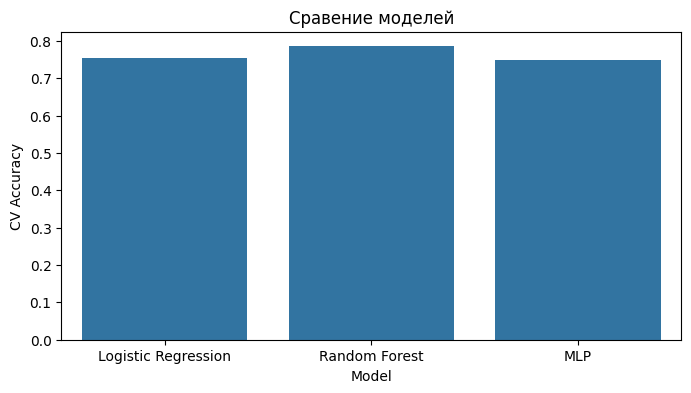

In [353]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=results,
    x='Model',
    y='CV Accuracy'
)

plt.title('Сравение моделей')
plt.show()

## 4.7 Подбор гиперпараметров

In [354]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20]
}

In [355]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [356]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

Лучшие параметры:

In [357]:
print(grid_rf.best_params_)

{'max_depth': None, 'n_estimators': 300}


Лучшая метрика:

In [358]:
print(grid_rf.best_score_)

0.7897361500269175


## 4.8 Выбор лучшей модели

In [359]:
best_model = grid_rf.best_estimator_
best_model

RandomForestClassifier(n_estimators=300, random_state=42)

## 4.9 Проверка на тестовой выборке

In [360]:
y_pred = best_model.predict(
    X_test
)

Accuracy

In [361]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.8080934501460159


Classification Report

In [362]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

        high       0.87      0.87      0.87       807
         low       0.82      0.85      0.83       789
      medium       0.73      0.71      0.72       801

    accuracy                           0.81      2397
   macro avg       0.81      0.81      0.81      2397
weighted avg       0.81      0.81      0.81      2397



Матрица ошибок:

In [363]:
cm = confusion_matrix(
    y_test,
    y_pred
)

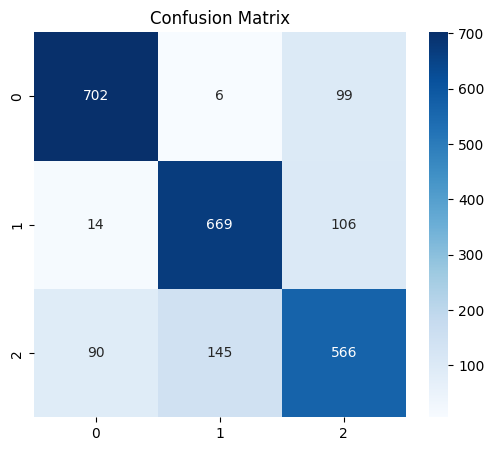

In [364]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.show()

##  4.10 Проверка на переобучение

In [365]:
train_score = best_model.score(
    X_train,
    y_train
)

test_score = best_model.score(
    X_test,
    y_test
)

In [366]:
print(train_score)
print(test_score)

1.0
0.8080934501460159


# Results

## Обучение финальной модели на всём датасете

In [371]:
y = df['price_category']

X = df.drop(columns=['price_category', 'price'])

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)


In [374]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ))
])

final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['odometer', 'lat', 'long', 'posting_dayofweek', 'car_age'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [368]:
print(X.shape)
print(X.select_dtypes(include='object').columns)

(9588, 16)
Index(['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
       'transmission', 'drive', 'type', 'paint_color', 'state'],
      dtype='object')


## Pickle

In [377]:
with open('final_model.pkl', 'wb') as file:
  pickle.dump(final_model, file)

Проверка загрузки модели

In [378]:
with open('final_model.pkl', 'rb') as file:
  loaded_model = pickle.load(file)

In [380]:
print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [382]:
loaded_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['odometer', 'lat', 'long', 'posting_dayofweek', 'car_age'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=300, random_state=42))])



> В рамках этапа моделирования были рассмотрены три алгоритма классификации: логистическая регрессия, случайный лес и многослойный персептрон.

Данные были разделены на обучающую и тестовую выборки в соотношении 75% и 25%

Для выбора наилучшей модели была проведена кросс-валидация на обучающей выборке. Получены следующие значения метрики accuracy:

* Logistic Regression — 0.755;
* Random Forest — 0.785;
* MLPClassifier — 0.750.

Наилучший результат показала модель Random Forest, поэтому для неё был выполнен подбор гиперпараметров с помощью GridSearchCV. Оптимальными параметрами оказались:

* n_estimators = 300;
* max_depth = None.

После обучения лучшей модели были рассчитаны значения accuracy на обучающей и тестовой выборках:

* обучающая выборка — 1.00;
* тестовая выборка — 0.81.

Несмотря на высокое качество на тестовой выборке, значение accuracy на обучающей выборке значительно выше, что свидетельствует о наличии переобучения. Модель хорошо запоминает обучающие данные, однако её качество на новых данных несколько снижается.

Таким образом, по результатам кросс-валидации лучшей моделью оказался Random Forest с точностью около 81% на тестовой выборке.


